In [1]:

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from IPython.display import display, Markdown

plt.rcParams["figure.dpi"] = 130
pd.set_option("display.max_colwidth", 200)


In this section, I study the model as a function $\hat p(x)$ mapping inputs to probabilities. I interpret each computation as evaluating properties of this function such as gradients, perturbations, or expectations.

## 1. Locate and validate the saved artefacts

In [2]:

# Change this if your outputs live elsewhere.
OUTDIR = Path("./analysis_outputs")

required_files = [
    "xgb_analysis_train.csv",
    "xgb_deciles.csv",
    "xgb_mean_abs_shap.csv",
    "xgb_mean_signed_shap.csv",
    "xgb_regime_signed_shap.csv",
    "xgb_case_type_signed_shap.csv",
    "xgb_interaction_candidates.csv",
    "xgb_xai_summary.json",
    "realmlp_analysis_train.csv",
    "realmlp_analysis_test.csv",
    "realmlp_fold_metrics.csv",
    "realmlp_schema_check.csv",
    "realmlp_deciles.csv",
    "realmlp_permutation_importance.csv",
    "realmlp_finite_difference_sensitivity.csv",
    "realmlp_grouped_ablation.csv",
    "realmlp_uncertainty_summary.csv",
    "realmlp_xai_summary.json",
]

missing = [f for f in required_files if not (OUTDIR / f).exists()]
if missing:
    raise FileNotFoundError(
        "The following expected artefacts were not found in "
        f"{OUTDIR.resolve()}:\n- " + "\n- ".join(missing)
    )

print("Using output directory:", OUTDIR.resolve())
print("All required exported tables and summaries were found.")


Using output directory: C:\Users\ADEY\Downloads\Kaggle Churn\Predicting-Churn\analysis_outputs
All required exported tables and summaries were found.


## 2. Load exported tables and summaries

In [3]:

xgb_train = pd.read_csv(OUTDIR / "xgb_analysis_train.csv")
xgb_dec = pd.read_csv(OUTDIR / "xgb_deciles.csv")
xgb_mean_abs_shap = pd.read_csv(OUTDIR / "xgb_mean_abs_shap.csv")
xgb_mean_signed_shap = pd.read_csv(OUTDIR / "xgb_mean_signed_shap.csv")
xgb_regime_signed = pd.read_csv(OUTDIR / "xgb_regime_signed_shap.csv", index_col=0)
xgb_case_type_signed = pd.read_csv(OUTDIR / "xgb_case_type_signed_shap.csv", index_col=0)
xgb_interactions = pd.read_csv(OUTDIR / "xgb_interaction_candidates.csv")
xgb_summary = json.loads((OUTDIR / "xgb_xai_summary.json").read_text())

real_train = pd.read_csv(OUTDIR / "realmlp_analysis_train.csv")
real_test = pd.read_csv(OUTDIR / "realmlp_analysis_test.csv")
real_fold_metrics = pd.read_csv(OUTDIR / "realmlp_fold_metrics.csv")
real_schema = pd.read_csv(OUTDIR / "realmlp_schema_check.csv")
real_dec = pd.read_csv(OUTDIR / "realmlp_deciles.csv")
real_perm = pd.read_csv(OUTDIR / "realmlp_permutation_importance.csv")
real_sens = pd.read_csv(OUTDIR / "realmlp_finite_difference_sensitivity.csv")
real_ablation = pd.read_csv(OUTDIR / "realmlp_grouped_ablation.csv")
real_unc = pd.read_csv(OUTDIR / "realmlp_uncertainty_summary.csv", index_col=0)
real_summary = json.loads((OUTDIR / "realmlp_xai_summary.json").read_text())

# normalise one XGBoost export depending on whether it came out as unnamed+value or named columns
if xgb_mean_abs_shap.shape[1] == 2 and "mean_abs_shap" in xgb_mean_abs_shap.columns:
    feature_col = [c for c in xgb_mean_abs_shap.columns if c != "mean_abs_shap"][0]
    xgb_mean_abs_shap = xgb_mean_abs_shap.rename(columns={feature_col: "feature"})
if xgb_mean_signed_shap.shape[1] == 2 and "mean_signed_shap" in xgb_mean_signed_shap.columns:
    feature_col = [c for c in xgb_mean_signed_shap.columns if c != "mean_signed_shap"][0]
    xgb_mean_signed_shap = xgb_mean_signed_shap.rename(columns={feature_col: "feature"})

print("Loaded all exported outputs.")
print("XGB train rows:", len(xgb_train))
print("RealMLP train rows:", len(real_train))


Loaded all exported outputs.
XGB train rows: 594194
RealMLP train rows: 594194


## 3. High-level comparison table

In [4]:

def _safe_float(d, key):
    val = d.get(key, np.nan)
    try:
        return float(val)
    except Exception:
        return np.nan

comparison_summary = pd.DataFrame([
    {
        "model": "XGBoost",
        "auc": _safe_float(xgb_summary, "train_auc_competition_only"),
        "logloss": _safe_float(xgb_summary, "train_logloss_competition_only"),
        "brier": _safe_float(xgb_summary, "train_brier_competition_only"),
        "n_features_runtime": xgb_summary.get("n_runtime_cols", np.nan),
        "n_feature_importance_table_rows": len(xgb_mean_abs_shap),
    },
    {
        "model": "RealMLP",
        "auc": _safe_float(real_summary, "oof_auc"),
        "logloss": _safe_float(real_summary, "oof_logloss"),
        "brier": _safe_float(real_summary, "oof_brier"),
        "n_features_runtime": real_summary.get("n_numeric_features", np.nan),
        "n_feature_importance_table_rows": len(real_perm),
    },
]).sort_values("auc", ascending=False).reset_index(drop=True)

display(comparison_summary)


,model,auc,logloss,brier,n_features_runtime,n_feature_importance_table_rows
0,XGBoost,0.933437,0.268055,0.085993,161,161
1,RealMLP,0.917199,0.298696,0.095583,22,22


The point is not only which model has the larger AUC, but also whether the gains are accompanied by better log-loss and Brier score. If one model is stronger on discrimination but not on probability quality, say that explicitly.


## 4. Calibration and risk concentration comparison

In [5]:

# make the decile tables easy to compare
xgb_dec_cmp = xgb_dec.rename(columns={
    "mean_pred": "xgb_mean_pred",
    "churn_rate": "xgb_observed_rate",
    "n": "xgb_n",
    "pred_min": "xgb_pred_min",
    "pred_max": "xgb_pred_max",
})
real_dec_cmp = real_dec.rename(columns={
    "mean_pred": "real_mean_pred",
    "churn_rate": "real_observed_rate",
    "n": "real_n",
    "pred_min": "real_pred_min",
    "pred_max": "real_pred_max",
})

dec_compare = xgb_dec_cmp.merge(real_dec_cmp, on="bin", how="inner")
display(dec_compare)


,bin,xgb_mean_pred,xgb_observed_rate,xgb_n,xgb_pred_min,xgb_pred_max,real_mean_pred,real_observed_rate,real_n,real_pred_min,real_pred_max
0,0,0.000052,0.000000,59420,0.000003,0.000110,0.002330,0.001094,59420,0.000880,0.003107
1,1,0.000682,0.000236,59419,0.000110,0.001696,0.004047,0.002710,59419,0.003107,0.005285
2,2,0.003563,0.002003,59419,0.001696,0.005920,0.007776,0.005840,59419,0.005285,0.011012
3,3,0.011040,0.007927,59420,0.005920,0.018740,0.017026,0.016829,59420,0.011013,0.025836
4,4,0.033567,0.028728,59419,0.018741,0.053924,0.042658,0.042966,59419,0.025837,0.065962
5,5,0.093750,0.084165,59419,0.053925,0.145461,0.106499,0.107390,59419,0.065962,0.156202
6,6,0.223051,0.217115,59420,0.145461,0.313004,0.221997,0.233793,59420,0.156208,0.294355
7,7,0.417723,0.411215,59419,0.313006,0.523134,0.375918,0.404180,59419,0.294356,0.460177
8,8,0.625240,0.635672,59419,0.523141,0.727878,0.551160,0.607600,59419,0.460180,0.647994
9,9,0.848388,0.865012,59420,0.727878,0.999883,0.768880,0.829670,59420,0.648000,0.966818


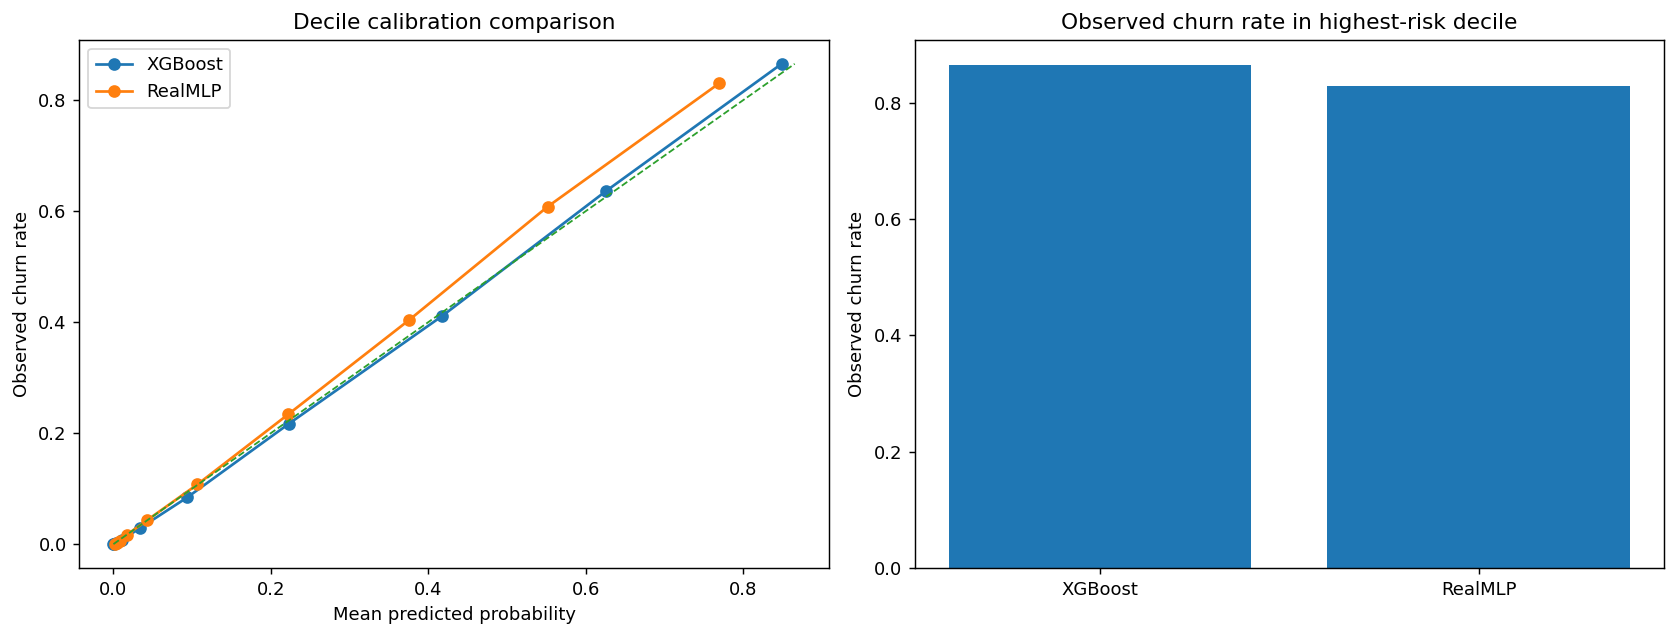

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# calibration-like line comparison
axes[0].plot(dec_compare["xgb_mean_pred"], dec_compare["xgb_observed_rate"], marker="o", label="XGBoost")
axes[0].plot(dec_compare["real_mean_pred"], dec_compare["real_observed_rate"], marker="o", label="RealMLP")
diag_min = min(dec_compare[["xgb_mean_pred","xgb_observed_rate","real_mean_pred","real_observed_rate"]].min())
diag_max = max(dec_compare[["xgb_mean_pred","xgb_observed_rate","real_mean_pred","real_observed_rate"]].max())
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], linestyle="--", linewidth=1)
axes[0].set_title("Decile calibration comparison")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed churn rate")
axes[0].legend()

# top-decile lift / concentration comparison
lift_df = pd.DataFrame({
    "model": ["XGBoost", "RealMLP"],
    "top_decile_observed_rate": [
        dec_compare["xgb_observed_rate"].iloc[-1],
        dec_compare["real_observed_rate"].iloc[-1],
    ],
    "bottom_decile_observed_rate": [
        dec_compare["xgb_observed_rate"].iloc[0],
        dec_compare["real_observed_rate"].iloc[0],
    ],
})
axes[1].bar(lift_df["model"], lift_df["top_decile_observed_rate"])
axes[1].set_title("Observed churn rate in highest-risk decile")
axes[1].set_ylabel("Observed churn rate")

plt.tight_layout()
plt.show()


These are cross-model plots and should be compared directly. In the left panel, the closer a model stays to the diagonal, the better its decile-level probability calibration. In the right panel, the higher the top-decile observed rate, the better the model is at concentrating true churners into the most actionable segment.


## 5. Global feature reliance: ranking comparison

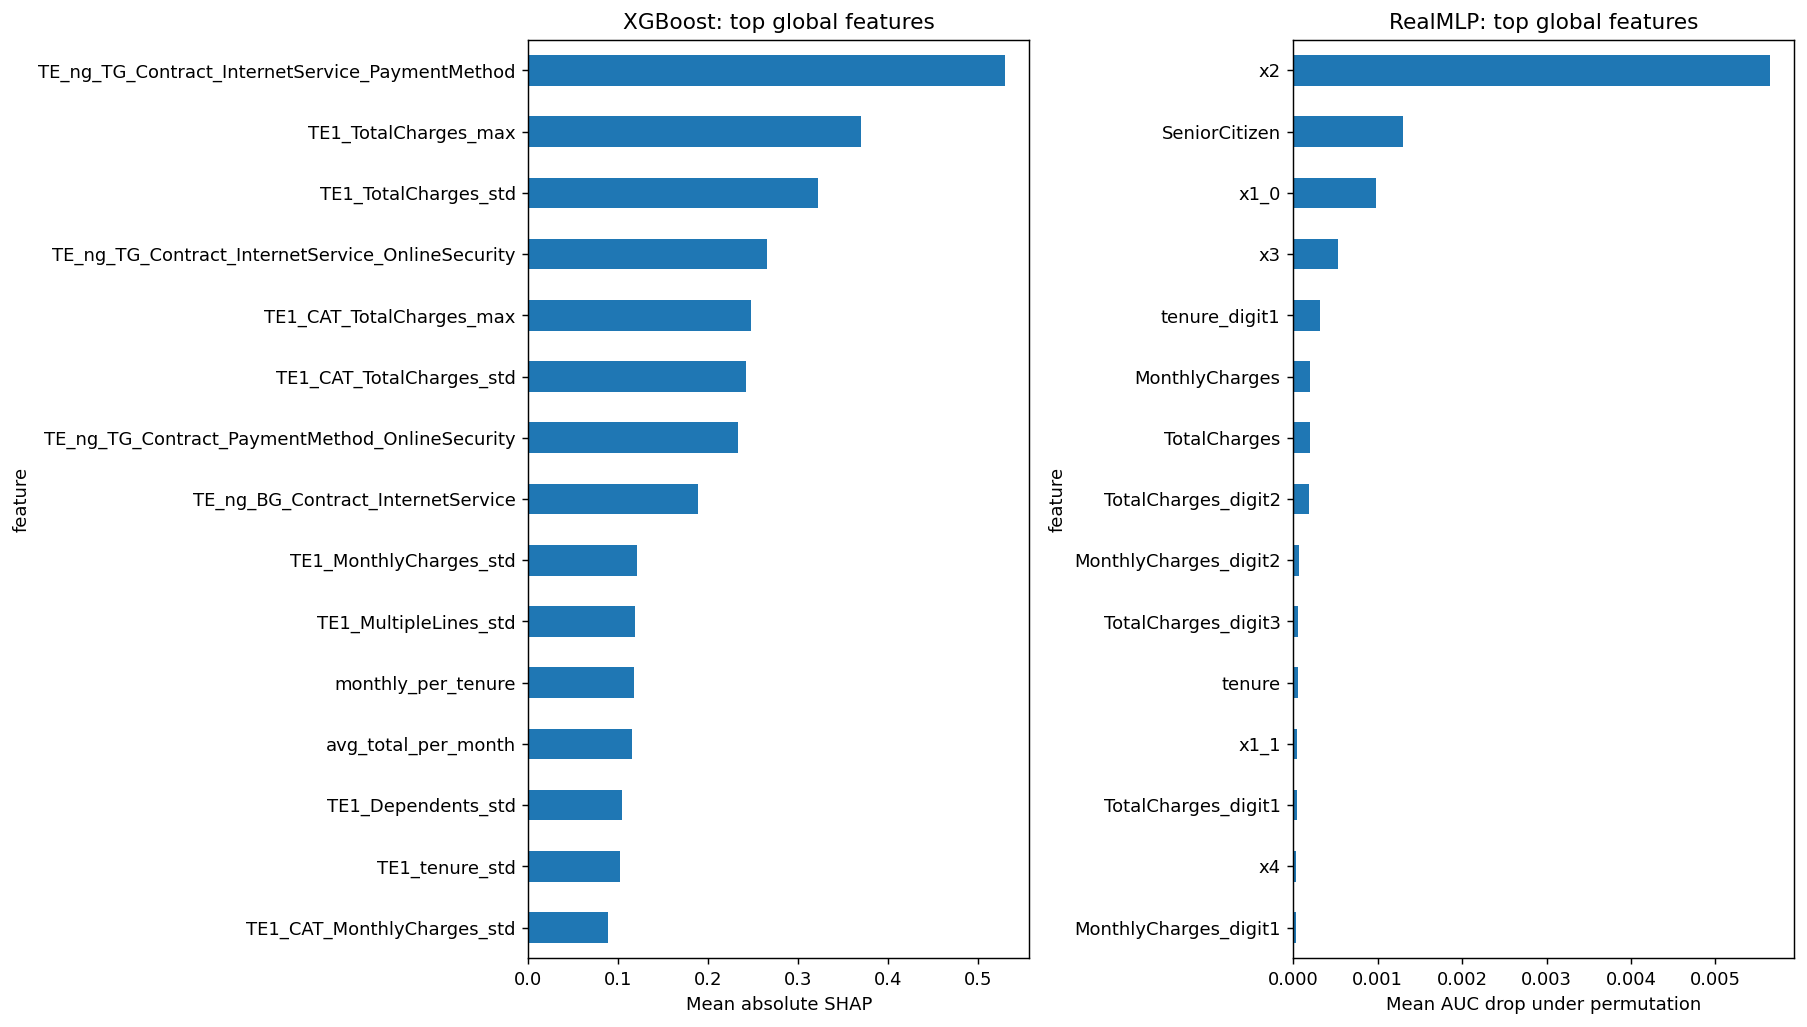

,xgb_top_features,realmlp_top_features
0,TE_ng_TG_Contract_InternetService_PaymentMethod,x2
1,TE1_TotalCharges_max,SeniorCitizen
2,TE1_TotalCharges_std,x1_0
3,TE_ng_TG_Contract_InternetService_OnlineSecurity,x3
4,TE1_CAT_TotalCharges_max,tenure_digit1
5,TE1_CAT_TotalCharges_std,MonthlyCharges
6,TE_ng_TG_Contract_PaymentMethod_OnlineSecurity,TotalCharges
7,TE_ng_BG_Contract_InternetService,TotalCharges_digit2
8,TE1_MonthlyCharges_std,MonthlyCharges_digit2
9,TE1_MultipleLines_std,TotalCharges_digit3


In [7]:

xgb_top = xgb_mean_abs_shap.sort_values("mean_abs_shap", ascending=False).head(15).copy()
real_top = real_perm.sort_values("mean_importance", ascending=False).head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

xgb_top.sort_values("mean_abs_shap").plot(
    x="feature", y="mean_abs_shap", kind="barh", legend=False, ax=axes[0]
)
axes[0].set_title("XGBoost: top global features")
axes[0].set_xlabel("Mean absolute SHAP")

real_top.sort_values("mean_importance").plot(
    x="feature", y="mean_importance", kind="barh", legend=False, ax=axes[1]
)
axes[1].set_title("RealMLP: top global features")
axes[1].set_xlabel("Mean AUC drop under permutation")

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "xgb_top_features": xgb_top["feature"].tolist(),
    "realmlp_top_features": real_top["feature"].tolist(),
}))


This is a cross-model comparison, but the scales are not the same, so compare **rankings and concentration**, not absolute magnitudes. If the tree model is dominated by a small number of engineered variables while the neural model spreads reliance across more inputs, that supports the claim that the two families exploit the feature space differently.


## 6. RealMLP-only internal sensitivity diagnostics

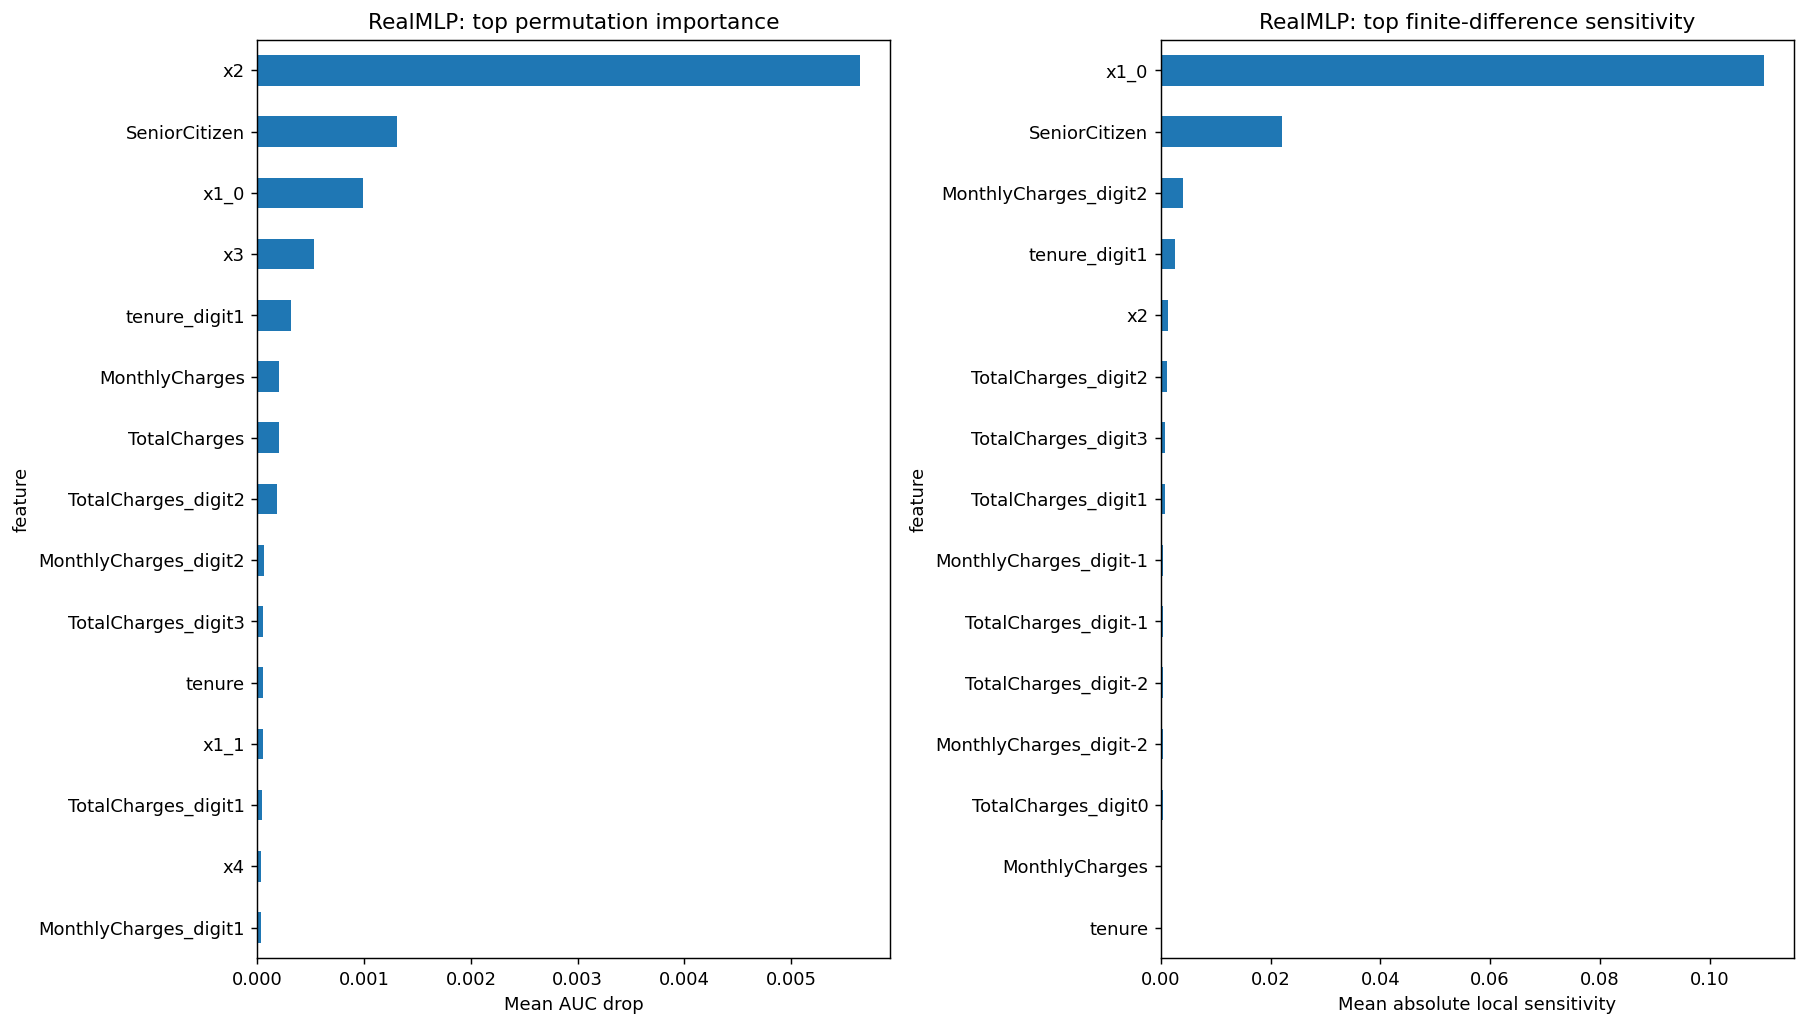

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

real_perm.head(15).sort_values("mean_importance").plot(
    x="feature", y="mean_importance", kind="barh", legend=False, ax=axes[0]
)
axes[0].set_title("RealMLP: top permutation importance")
axes[0].set_xlabel("Mean AUC drop")

real_sens.head(15).sort_values("mean_abs_sensitivity").plot(
    x="feature", y="mean_abs_sensitivity", kind="barh", legend=False, ax=axes[1]
)
axes[1].set_title("RealMLP: top finite-difference sensitivity")
axes[1].set_xlabel("Mean absolute local sensitivity")

plt.tight_layout()
plt.show()


This is a **within-RealMLP** analysis and should be interpreted in isolation, not numerically compared against XGBoost. Compare the two panels to see whether the features that matter most globally are also the most locally responsive. Large permutation importance with modest sensitivity can indicate a feature that matters through broader structural effects rather than steep local gradients.


## 7. RealMLP-only grouped ablation

,group,mean_abs_delta,mean_signed_delta,max_abs_delta
0,streaming_phone,0.035071,0.034967,0.223998
1,contract_payment,0.027666,-0.027666,0.198302
2,internet_support,0.024606,-0.024606,0.317824
3,household,0.005301,-0.004702,0.110057


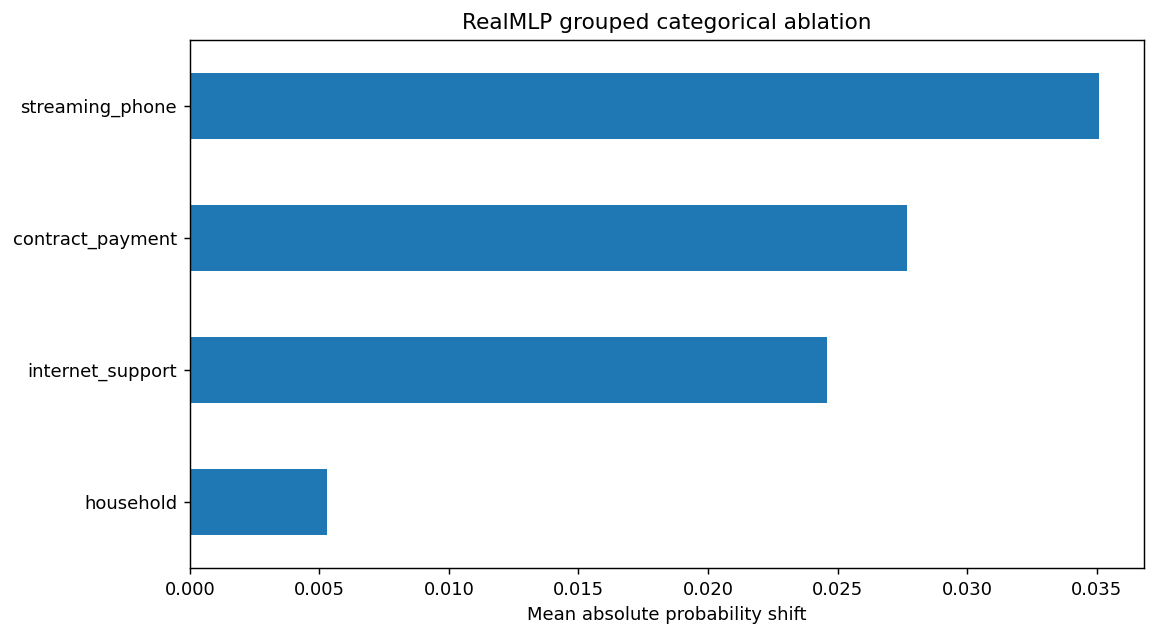

In [9]:

display(real_ablation)

ax = real_ablation.sort_values("mean_abs_delta").plot(
    x="group",
    y="mean_abs_delta",
    kind="barh",
    legend=False,
    figsize=(9, 5),
)
ax.set_title("RealMLP grouped categorical ablation")
ax.set_xlabel("Mean absolute probability shift")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


This is also a **within-RealMLP** test. It tells you which semantic subsystems the network uses most strongly. Use it to say whether the network is driven more by contractual/payment structure, service bundle structure, or demographic structure. Do not compare the raw magnitudes here against SHAP values from XGBoost.


## 8. RealMLP uncertainty and disagreement

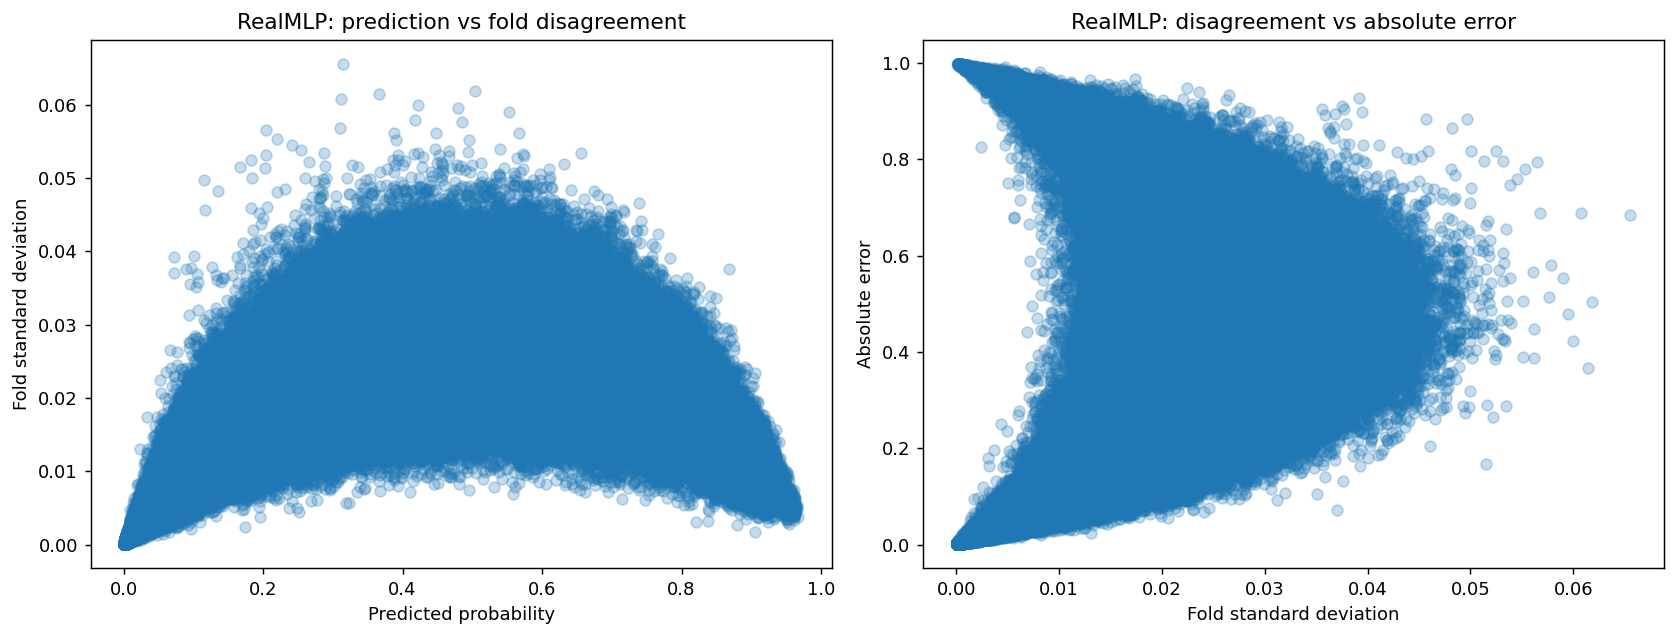

,mean_pred,observed_rate,mean_abs_error,n
fold_std,,,,
"(-0.0009382, 0.000666]",0.003392,0.001750,0.005128,118839
"(0.000666, 0.00317]",0.012918,0.011335,0.023767,118839
"(0.00317, 0.0136]",0.147528,0.151021,0.138210,118838
"(0.0136, 0.0233]",0.411039,0.442700,0.354451,118839
"(0.0233, 0.0656]",0.474269,0.519232,0.449057,118839


In [10]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(real_train["realmlp_pred"], real_train["fold_std"], alpha=0.25)
axes[0].set_title("RealMLP: prediction vs fold disagreement")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Fold standard deviation")

axes[1].scatter(real_train["fold_std"], real_train["abs_error"], alpha=0.25)
axes[1].set_title("RealMLP: disagreement vs absolute error")
axes[1].set_xlabel("Fold standard deviation")
axes[1].set_ylabel("Absolute error")

plt.tight_layout()
plt.show()

display(real_unc)


This is a **within-RealMLP** uncertainty analysis. In the left panel, look for whether disagreement is concentrated near the middle of the score range rather than the extremes. In the right panel, look for whether larger disagreement tends to coincide with larger error. If it does, then fold dispersion is acting as a meaningful uncertainty proxy rather than just random variation.


## 9. XGBoost regime and case-type explanation structure

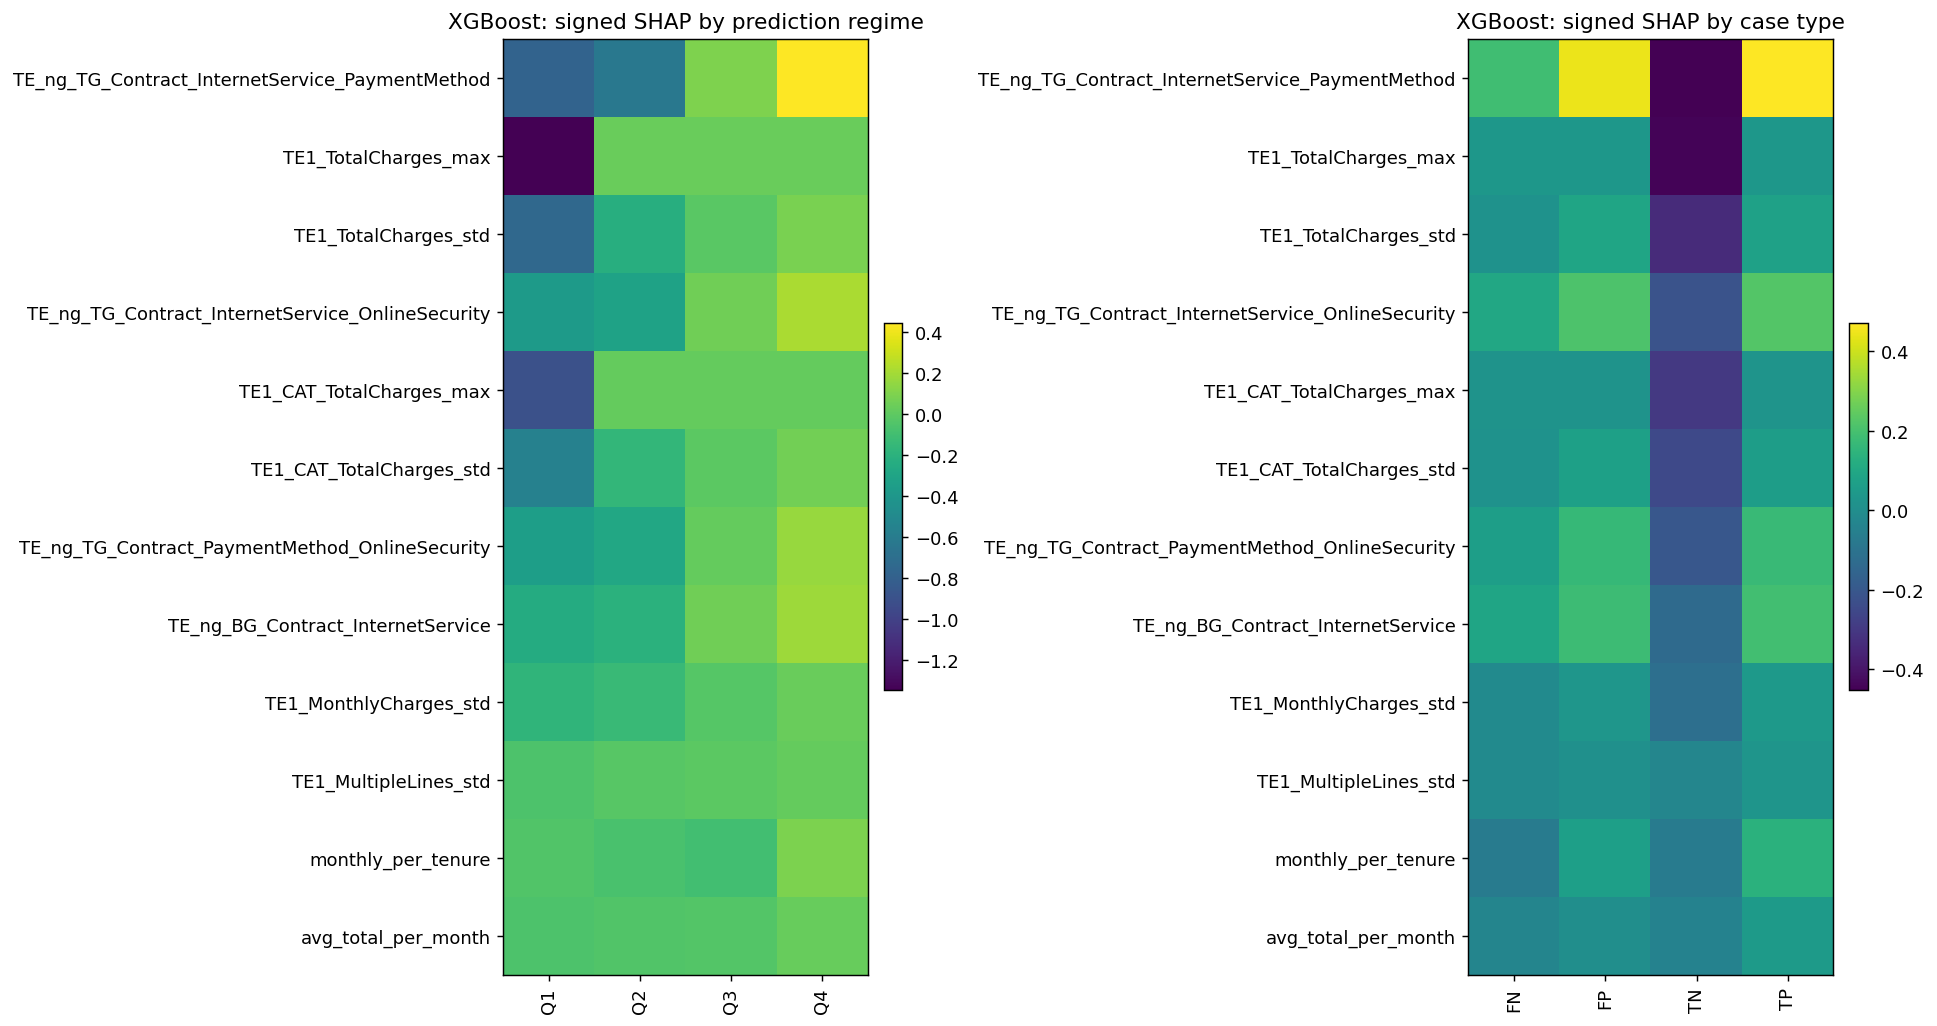

In [11]:

# choose a compact set of influential XGB features for visual comparison
top_xgb_features = xgb_mean_abs_shap.sort_values("mean_abs_shap", ascending=False)["feature"].head(12).tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

regime_plot = xgb_regime_signed[top_xgb_features] if set(top_xgb_features).issubset(xgb_regime_signed.columns) else xgb_regime_signed.iloc[:, :12]
im0 = axes[0].imshow(regime_plot.values, aspect="auto")
axes[0].set_title("XGBoost: signed SHAP by prediction regime")
axes[0].set_yticks(range(len(regime_plot.index)))
axes[0].set_yticklabels(regime_plot.index)
axes[0].set_xticks(range(len(regime_plot.columns)))
axes[0].set_xticklabels(regime_plot.columns, rotation=90)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

case_plot = xgb_case_type_signed[top_xgb_features] if set(top_xgb_features).issubset(xgb_case_type_signed.columns) else xgb_case_type_signed.iloc[:, :12]
im1 = axes[1].imshow(case_plot.values, aspect="auto")
axes[1].set_title("XGBoost: signed SHAP by case type")
axes[1].set_yticks(range(len(case_plot.index)))
axes[1].set_yticklabels(case_plot.index)
axes[1].set_xticks(range(len(case_plot.columns)))
axes[1].set_xticklabels(case_plot.columns, rotation=90)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


This is an **XGBoost-only** interpretability section. It should be taken in isolation. The left panel asks how the signed contribution of important features changes as you move from low-risk to high-risk score regimes. The right panel asks whether the model is using the same features differently in true positives, false positives, true negatives, and false negatives. This is where you diagnose failure modes in the tree model rather than compare absolute attribution values against the neural model.


### Mathematical framing

In this section, I study the model as a function $\hat p(x)$ mapping inputs to probabilities. I interpret each computation as evaluating properties of this function such as gradients, perturbations, or expectations.

## 10. Previously generated model-specific figures for the appendix or report

In [12]:

existing_figures = [
    "xgb_01_core_diagnostics.png",
    "xgb_02_mean_abs_shap.png",
    "xgb_03_shap_beeswarm.png",
    "xgb_04_regime_signed_shap_heatmap.png",
    "xgb_05_signed_shap_by_case_type.png",
    "realmlp_01_core_diagnostics.png",
    "realmlp_02_permutation_importance.png",
    "realmlp_03_finite_difference_sensitivity.png",
    "realmlp_04_grouped_ablation.png",
    "realmlp_05_disagreement_vs_error.png",
]

available_figures = [f for f in existing_figures if (OUTDIR / f).exists()]
print("Available pre-rendered figures:")
for f in available_figures:
    print("-", f)


Available pre-rendered figures:
- xgb_01_core_diagnostics.png
- xgb_02_mean_abs_shap.png
- xgb_03_shap_beeswarm.png
- xgb_04_regime_signed_shap_heatmap.png
- xgb_05_signed_shap_by_case_type.png
- realmlp_01_core_diagnostics.png
- realmlp_02_permutation_importance.png
- realmlp_03_finite_difference_sensitivity.png
- realmlp_04_grouped_ablation.png
- realmlp_05_disagreement_vs_error.png


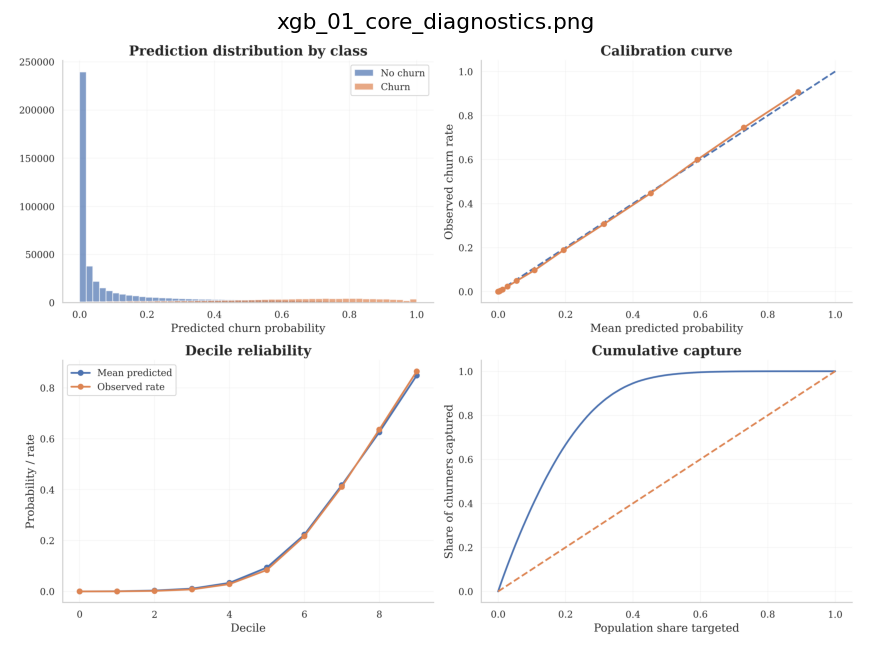

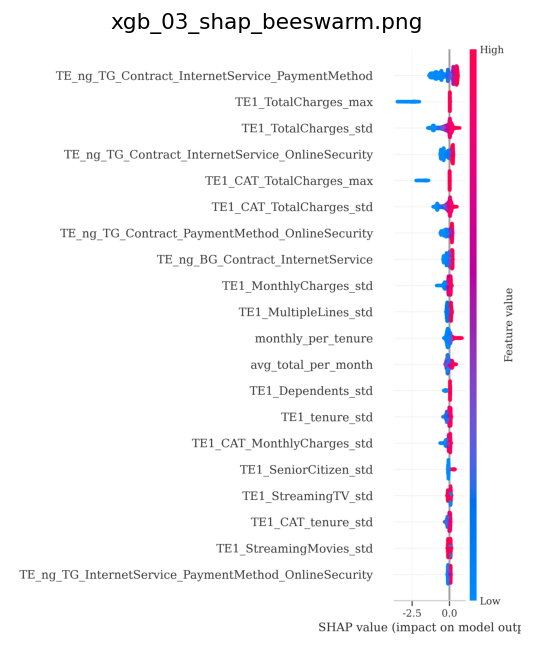

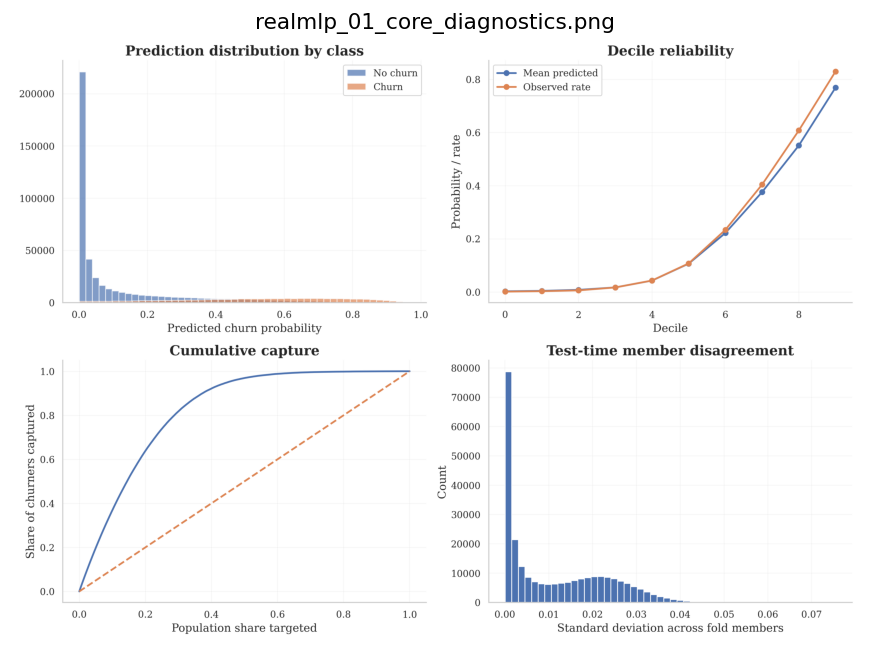

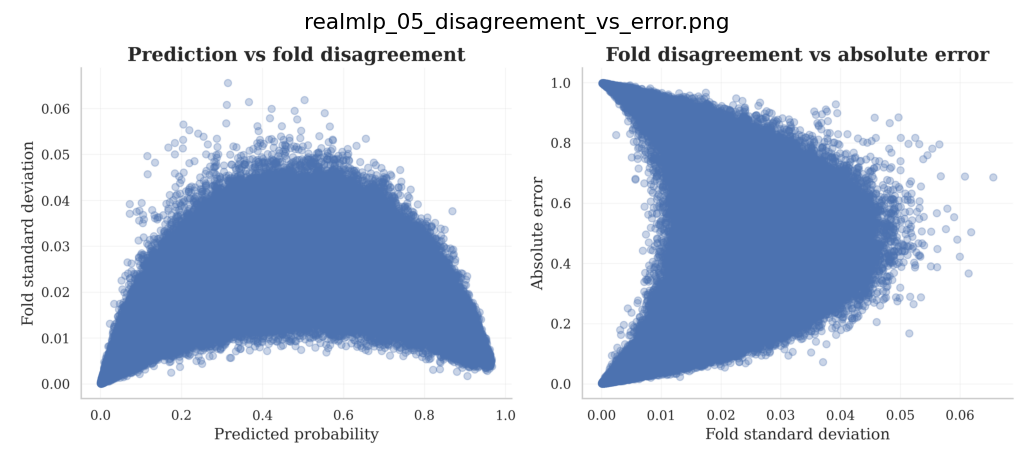

In [13]:

# Display a small curated subset without recreating them.
to_show = [
    "xgb_01_core_diagnostics.png",
    "xgb_03_shap_beeswarm.png",
    "realmlp_01_core_diagnostics.png",
    "realmlp_05_disagreement_vs_error.png",
]

for fname in to_show:
    fpath = OUTDIR / fname
    if fpath.exists():
        img = mpimg.imread(fpath)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis("off")
        plt.title(fname)
        plt.show()


These are the original notebook figures, kept for direct reuse in the report appendix. They are best used as supporting material after the synthesis plots above. In the report body, lead with the comparison tables and comparison plots first, then use these as model-specific evidence.


### Mathematical framing

In this section, I study the model as a function $\hat p(x)$ mapping inputs to probabilities. I interpret each computation as evaluating properties of this function such as gradients, perturbations, or expectations.

## 11. Final report-ready tables

In [14]:

# concise report tables
report_table_metrics = comparison_summary.copy()

report_table_top_features = pd.DataFrame({
    "XGBoost top SHAP features": xgb_mean_abs_shap.sort_values("mean_abs_shap", ascending=False)["feature"].head(10).tolist(),
    "RealMLP top permutation features": real_perm.sort_values("mean_importance", ascending=False)["feature"].head(10).tolist(),
})

# risk concentration summary
report_table_risk = pd.DataFrame([
    {
        "model": "XGBoost",
        "lowest_decile_observed_rate": dec_compare["xgb_observed_rate"].iloc[0],
        "highest_decile_observed_rate": dec_compare["xgb_observed_rate"].iloc[-1],
        "spread": dec_compare["xgb_observed_rate"].iloc[-1] - dec_compare["xgb_observed_rate"].iloc[0],
    },
    {
        "model": "RealMLP",
        "lowest_decile_observed_rate": dec_compare["real_observed_rate"].iloc[0],
        "highest_decile_observed_rate": dec_compare["real_observed_rate"].iloc[-1],
        "spread": dec_compare["real_observed_rate"].iloc[-1] - dec_compare["real_observed_rate"].iloc[0],
    },
])

display(report_table_metrics)
display(report_table_risk)
display(report_table_top_features)


,model,auc,logloss,brier,n_features_runtime,n_feature_importance_table_rows
0,XGBoost,0.933437,0.268055,0.085993,161,161
1,RealMLP,0.917199,0.298696,0.095583,22,22


,model,lowest_decile_observed_rate,highest_decile_observed_rate,spread
0,XGBoost,0.000000,0.865012,0.865012
1,RealMLP,0.001094,0.829670,0.828576


,XGBoost top SHAP features,RealMLP top permutation features
0,TE_ng_TG_Contract_InternetService_PaymentMethod,x2
1,TE1_TotalCharges_max,SeniorCitizen
2,TE1_TotalCharges_std,x1_0
3,TE_ng_TG_Contract_InternetService_OnlineSecurity,x3
4,TE1_CAT_TotalCharges_max,tenure_digit1
5,TE1_CAT_TotalCharges_std,MonthlyCharges
6,TE_ng_TG_Contract_PaymentMethod_OnlineSecurity,TotalCharges
7,TE_ng_BG_Contract_InternetService,TotalCharges_digit2
8,TE1_MonthlyCharges_std,MonthlyCharges_digit2
9,TE1_MultipleLines_std,TotalCharges_digit3


In [15]:

REPORT_DIR = OUTDIR / "report_tables"
REPORT_DIR.mkdir(exist_ok=True)

report_table_metrics.to_csv(REPORT_DIR / "report_metrics.csv", index=False)
report_table_risk.to_csv(REPORT_DIR / "report_risk_concentration.csv", index=False)
report_table_top_features.to_csv(REPORT_DIR / "report_top_features.csv", index=False)
dec_compare.to_csv(REPORT_DIR / "report_decile_comparison.csv", index=False)

print("Saved report tables to:", REPORT_DIR.resolve())


Saved report tables to: C:\Users\ADEY\Downloads\Kaggle Churn\Predicting-Churn\analysis_outputs\report_tables
